EDA

In [41]:
import pandas as pd
df = pd.read_csv('cleaned_data.csv')

df.head(100)


,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,male,instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,female,instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,male,snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,female,snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,male,snapchat,383,211,1,2,7.1,22,3,7,6,Stressed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Aadhya Ansari,25,7/24/2024,male,twitter,499,200,1,2,6.5,10,3,8,5,Stressed
96,Reyansh Nair,54,8/4/2024,male,twitter,212,85,1,1,7.9,39,2,6,6,Stressed
97,Navya Chauhan,22,7/29/2024,female,instagram,455,228,1,3,6.7,14,3,8,5,Stressed
98,Vihaan Saxena,36,8/3/2024,female,snapchat,252,139,1,1,7.7,35,2,6,6,Stressed


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("Set2")

TARGET = " mental_state"

In [43]:
def basic_info(df):
    print("\n[INFO] SHAPE:", df.shape)
    print("\n[INFO] INFO:")
    print(df.info())
    print("\n[INFO] DESCRIBE:")
    print(df.describe())

In [44]:
basic_info(df)


[INFO] SHAPE: (5000, 15)

[INFO] INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 no

In [45]:
def plot_distributions(df):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns

    for col in num_cols:
        plt.figure()
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

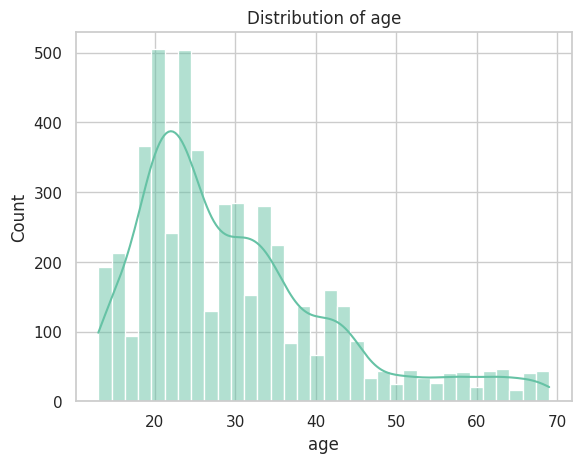

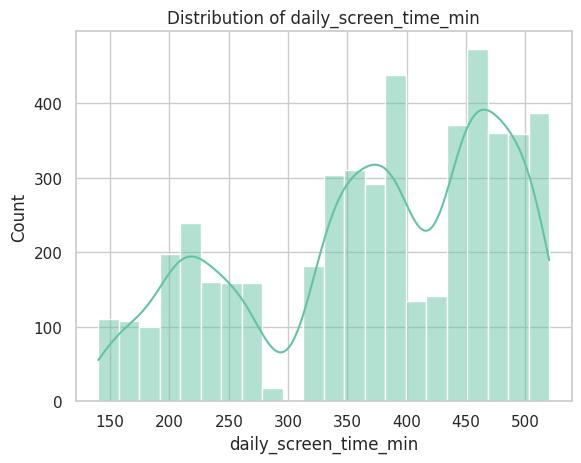

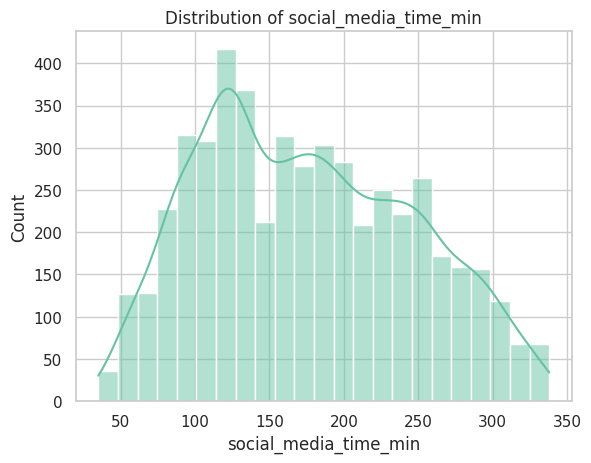

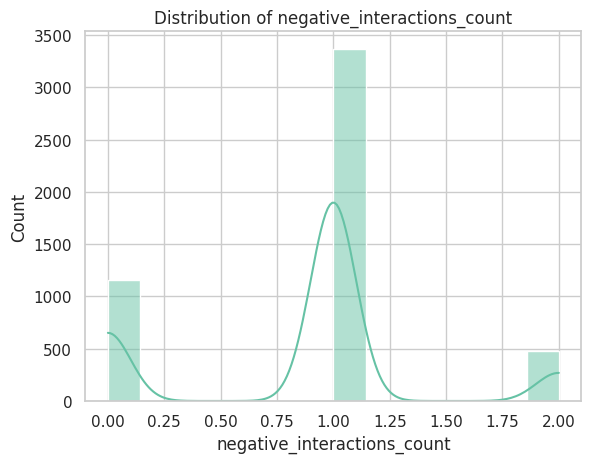

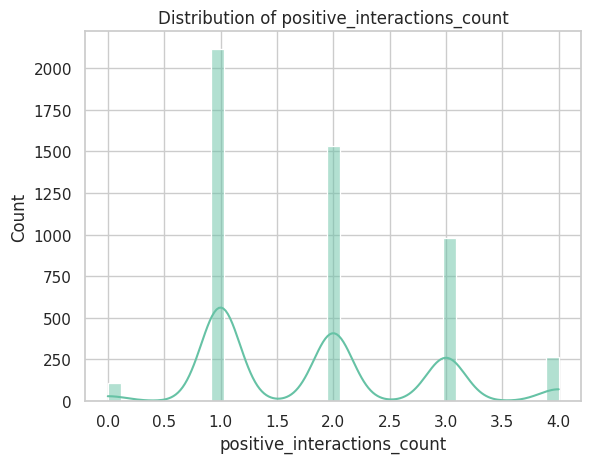

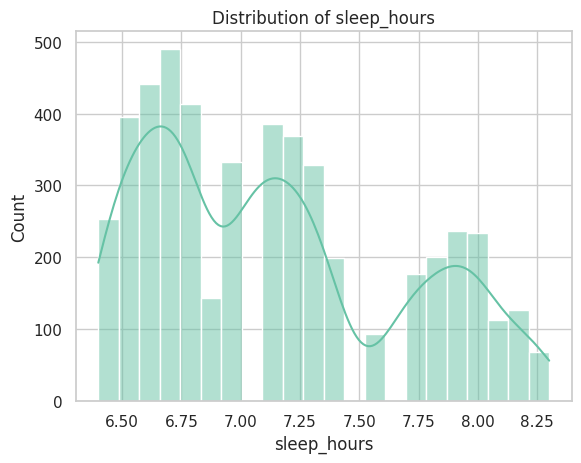

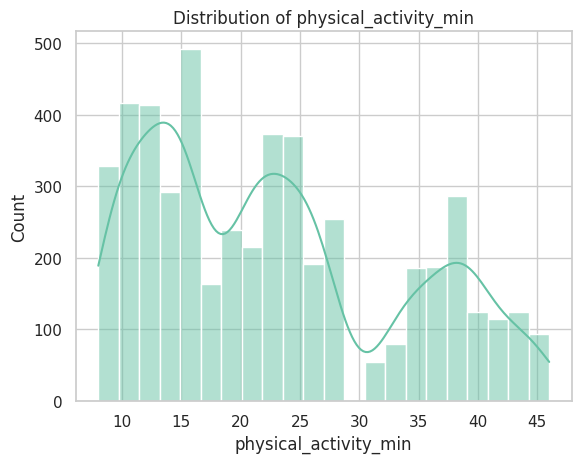

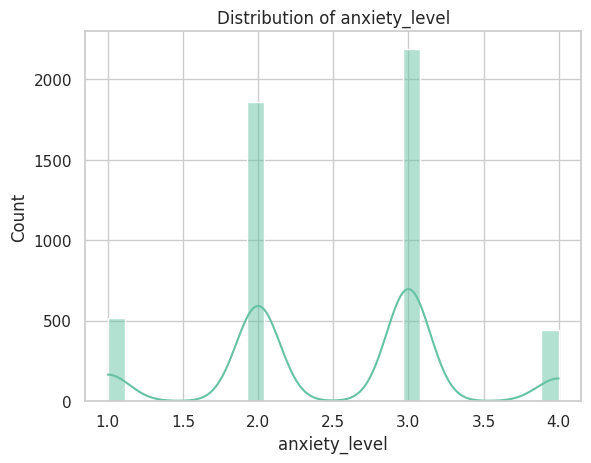

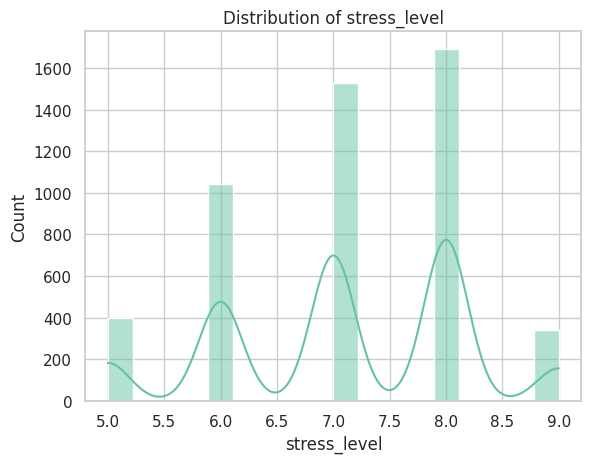

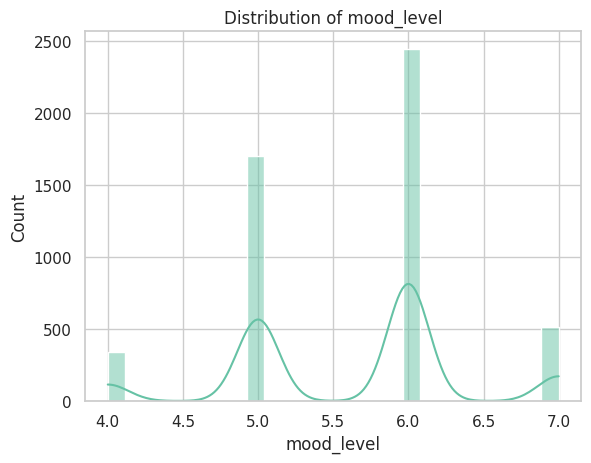

In [46]:
plot_distributions(df)

In [47]:
def correlation_matrix(df):
    plt.figure(figsize=(10,6))
    sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()

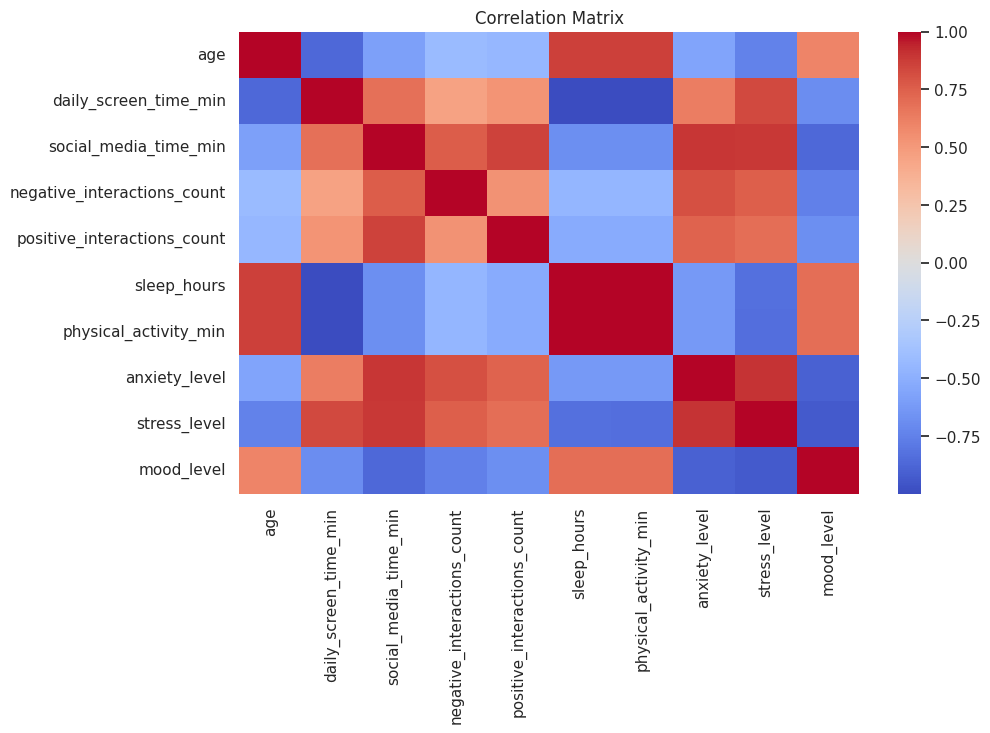

In [48]:
correlation_matrix(df)

In [49]:
def target_analysis(df):
    if TARGET in df.columns:
        plt.figure()
        sns.countplot(x=TARGET, data=df)
        plt.title("Mental State Distribution")
        plt.show()

In [50]:
target_analysis(df)

In [51]:
df.columns

Index(['person_name', 'age', 'date', 'gender', 'platform',
       'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state'],
      dtype='object')

Feature engineering

In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("cleaned_data.csv")

print("Original shape:", df.shape)
print("\nOriginal columns:")
print(df.columns.tolist())

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)


def get_season(month):
    if pd.isna(month):
        return np.nan
    elif month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


df["season"] = df["month"].apply(get_season)

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 24, 34, 49, 100],
    labels=["<25", "25-34", "35-49", "50+"]
)

df["social_media_ratio"] = df["social_media_time_min"] / (df["daily_screen_time_min"] + 1)
df["neg_pos_ratio"] = df["negative_interactions_count"] / (df["positive_interactions_count"] + 1)
df["activity_sleep_ratio"] = df["physical_activity_min"] / (df["sleep_hours"] + 1)
df["screen_sleep_ratio"] = df["daily_screen_time_min"] / (df["sleep_hours"] + 1)

df["digital_overload"] = df["daily_screen_time_min"] - df["physical_activity_min"]
df["screen_minus_social"] = df["daily_screen_time_min"] - df["social_media_time_min"]
df["interaction_balance"] = df["positive_interactions_count"] - df["negative_interactions_count"]
df["wellbeing_gap"] = (
    df["physical_activity_min"] + (df["sleep_hours"] * 60)
    - df["daily_screen_time_min"]
)

df["screen_x_sleep"] = df["daily_screen_time_min"] * df["sleep_hours"]
df["social_x_negative"] = df["social_media_time_min"] * df["negative_interactions_count"]
df["activity_x_positive"] = df["physical_activity_min"] * df["positive_interactions_count"]
df["stress_x_anxiety"] = df["stress_level"] * df["anxiety_level"]
df["mood_x_sleep"] = df["mood_level"] * df["sleep_hours"]

df["high_screen_time"] = (df["daily_screen_time_min"] > 300).astype(int)
df["low_sleep"] = (df["sleep_hours"] < 6).astype(int)
df["low_activity"] = (df["physical_activity_min"] < 30).astype(int)
df["high_negative_interaction"] = (df["negative_interactions_count"] > 10).astype(int)

df = df.drop(columns=["person_name", "date"])

categorical_cols = ["gender", "platform", "season", "age_group"]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nFeature engineered shape:", df.shape)
print("\nFeature engineered columns:")
print(df.columns.tolist())

df.to_csv("feature_engineered_data.csv", index=False)
print(f"\nSaved successfully as 'feature_engineered_data.csv'")


Original shape: (5000, 15)

Original columns:
['person_name', 'age', 'date', 'gender', 'platform', 'daily_screen_time_min', 'social_media_time_min', 'negative_interactions_count', 'positive_interactions_count', 'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level', 'mood_level', 'mental_state']

Feature engineered shape: (5000, 46)

Feature engineered columns:
['age', 'daily_screen_time_min', 'social_media_time_min', 'negative_interactions_count', 'positive_interactions_count', 'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level', 'mood_level', 'mental_state', 'day_of_week', 'month', 'day', 'is_weekend', 'social_media_ratio', 'neg_pos_ratio', 'activity_sleep_ratio', 'screen_sleep_ratio', 'digital_overload', 'screen_minus_social', 'interaction_balance', 'wellbeing_gap', 'screen_x_sleep', 'social_x_negative', 'activity_x_positive', 'stress_x_anxiety', 'mood_x_sleep', 'high_screen_time', 'low_sleep', 'low_activity', 'high_negative_interaction', 'gender

train_test_split

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("feature_engineered_data.csv")

y = df["mental_state"]
X = df.drop("mental_state", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("\nSaved successfully:")
print("- X_train.csv")
print("- X_test.csv")
print("- y_train.csv")
print("- y_test.csv")


X shape: (5000, 45)
y shape: (5000,)
X_train shape: (3500, 45)
X_test shape: (1500, 45)
y_train shape: (3500,)
y_test shape: (1500,)

Saved successfully:
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv


PCA

In [54]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pd.DataFrame(X_train_scaled).to_csv("X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled).to_csv("X_test_scaled.csv", index=False)

print("Scaling done.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nPCA done.")
print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)
print("Number of PCA components selected:", pca.n_components_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_columns = [f"PC{i+1}" for i in range(pca.n_components_)]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns)

X_train_pca_df.to_csv("X_train_pca.csv", index=False)
X_test_pca_df.to_csv("X_test_pca.csv", index=False)

# Optional explained variance report
explained_variance_df = pd.DataFrame({
    "principal_component": pca_columns,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": pca.explained_variance_ratio_.cumsum()
})
explained_variance_df.to_csv("pca_explained_variance.csv", index=False)

print("\nSaved successfully:")
print("- X_train_pca.csv")
print("- X_test_pca.csv")
print("- pca_explained_variance.csv")


Scaling done.
X_train_scaled shape: (3500, 45)
X_test_scaled shape: (1500, 45)

PCA done.
X_train_pca shape: (3500, 16)
X_test_pca shape: (1500, 16)
Number of PCA components selected: 16
Total explained variance: 0.9593001295785383

Saved successfully:
- X_train_pca.csv
- X_test_pca.csv
- pca_explained_variance.csv


MODELLING

In [55]:
import pandas as pd

# Original data
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# PCA data
X_train_pca = pd.read_csv("X_train_pca.csv")
X_test_pca = pd.read_csv("X_test_pca.csv")


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


In [57]:

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=7
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=20,
        max_features="sqrt",
        class_weight="balanced",
        random_state=7,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=7
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    )
}


clf_accuracies = {}

for name, model in models.items():

    if name == "RandomForest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    clf_accuracies[name] = round(accuracy, 3)

print(clf_accuracies)

print("\n===== Results for PCA =====\n")

clf_accuracies_pca = {}

for name, model in models.items():

    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    accuracy = accuracy_score(y_test, y_pred)
    clf_accuracies_pca[name] = round(accuracy, 3)

print(clf_accuracies_pca)


print("\n===== Comparison =====\n")

for model in clf_accuracies:
    orig = clf_accuracies[model]
    pca  = clf_accuracies_pca[model]

    better = "PCA" if pca > orig else "Original"

    print(f"{model}: Original={orig}, PCA={pca} → Better: {better}")

{'LogisticRegression': 0.989, 'RandomForest': 1.0, 'SVM': 0.988, 'KNN': 0.983}

===== Results for PCA =====

{'LogisticRegression': 0.989, 'RandomForest': 0.995, 'SVM': 0.987, 'KNN': 0.981}

===== Comparison =====

LogisticRegression: Original=0.989, PCA=0.989 → Better: Original
RandomForest: Original=1.0, PCA=0.995 → Better: Original
SVM: Original=0.988, PCA=0.987 → Better: Original
KNN: Original=0.983, PCA=0.981 → Better: Original


Comparison

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n===== Results for Original Data =====\n")

clf_metrics = {}

for name, model in models.items():

    if name == "RandomForest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    clf_metrics[name] = {
    "accuracy": round(accuracy_score(y_test, y_pred), 3),
    "precision": round(precision_score(y_test, y_pred, average="weighted"), 3),
    "recall": round(recall_score(y_test, y_pred, average="weighted"), 3),
    "f1": round(f1_score(y_test, y_pred, average="weighted"), 3)
}


print(clf_metrics)


print("\n===== Results for PCA =====\n")

clf_metrics_pca = {}

for name, model in models.items():

    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    clf_metrics_pca[name] = {
    "accuracy": round(accuracy_score(y_test, y_pred), 3),
    "precision": round(precision_score(y_test, y_pred, average="weighted"), 3),
    "recall": round(recall_score(y_test, y_pred, average="weighted"), 3),
    "f1": round(f1_score(y_test, y_pred, average="weighted"), 3)
}


print(clf_metrics_pca)


print("\n===== Comparison (based on F1-score) =====\n")

for model in clf_metrics:
    orig_f1 = clf_metrics[model]["f1"]
    pca_f1  = clf_metrics_pca[model]["f1"]

    better = "PCA" if pca_f1 > orig_f1 else "Original"

    print(f"{model}: Original F1={orig_f1}, PCA F1={pca_f1} → Better: {better}")



===== Results for Original Data =====

{'LogisticRegression': {'accuracy': 0.989, 'precision': 0.994, 'recall': 0.989, 'f1': 0.991}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}, 'SVM': {'accuracy': 0.988, 'precision': 0.994, 'recall': 0.988, 'f1': 0.99}, 'KNN': {'accuracy': 0.983, 'precision': 0.985, 'recall': 0.983, 'f1': 0.984}}

===== Results for PCA =====

{'LogisticRegression': {'accuracy': 0.989, 'precision': 0.993, 'recall': 0.989, 'f1': 0.99}, 'RandomForest': {'accuracy': 0.995, 'precision': 0.996, 'recall': 0.995, 'f1': 0.995}, 'SVM': {'accuracy': 0.987, 'precision': 0.994, 'recall': 0.987, 'f1': 0.989}, 'KNN': {'accuracy': 0.981, 'precision': 0.983, 'recall': 0.981, 'f1': 0.982}}

===== Comparison (based on F1-score) =====

LogisticRegression: Original F1=0.991, PCA F1=0.99 → Better: Original
RandomForest: Original F1=1.0, PCA F1=0.995 → Better: Original
SVM: Original F1=0.99, PCA F1=0.989 → Better: Original
KNN: Original F1=0.984, PCA F1=0.

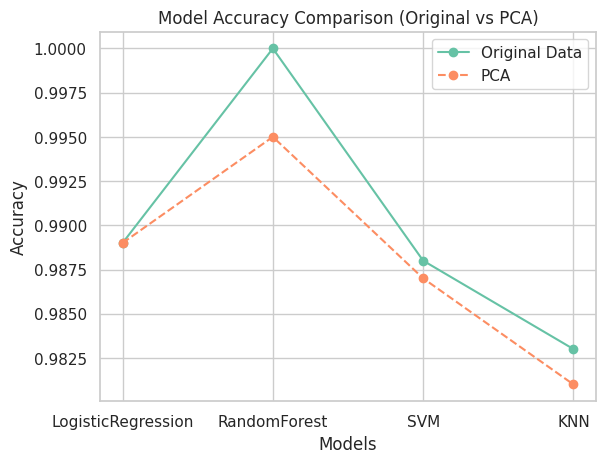

In [59]:
import matplotlib.pyplot as plt

models_list = list(clf_metrics.keys())

orig_acc = [clf_metrics[m]["accuracy"] for m in models_list]
pca_acc  = [clf_metrics_pca[m]["accuracy"] for m in models_list]


x = range(len(models_list))

plt.figure()

plt.plot(x, orig_acc, marker='o', label="Original Data")

plt.plot(x, pca_acc, marker='o', linestyle='--', label="PCA")

plt.xticks(x, models_list)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Original vs PCA)")
plt.legend()

plt.show()



===== Confusion Matrices: Original Data =====



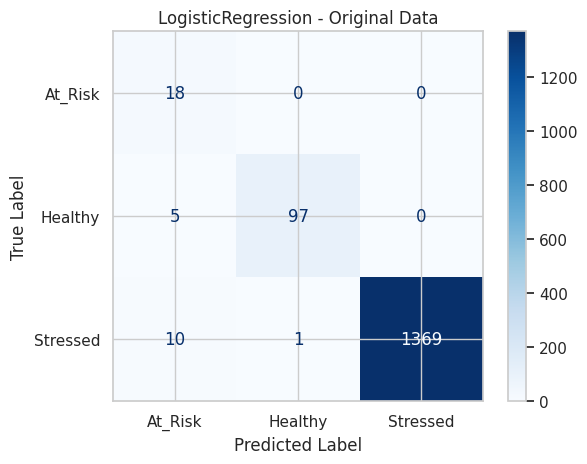

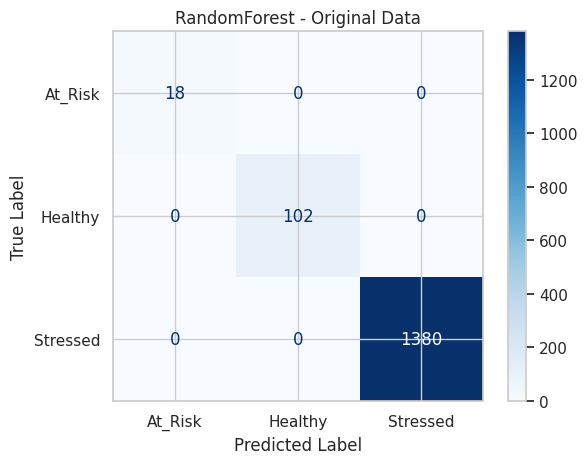

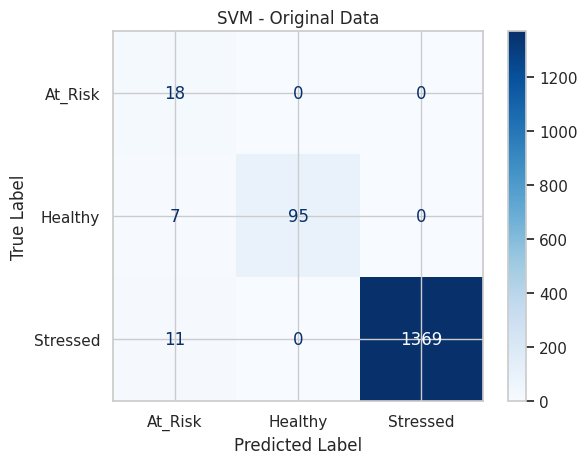

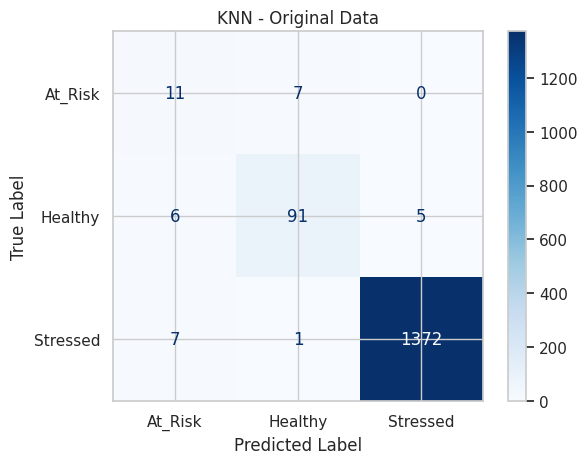


===== Confusion Matrices: PCA =====



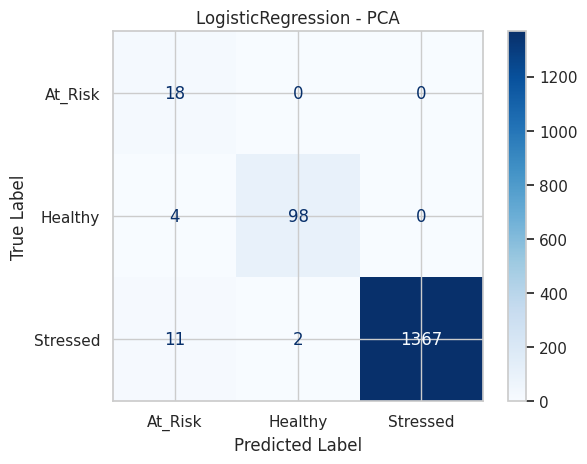

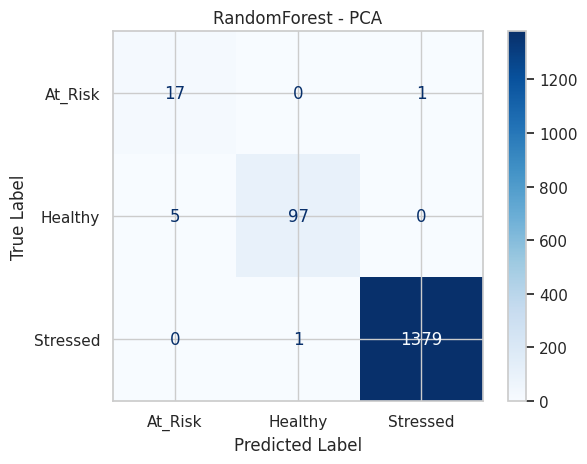

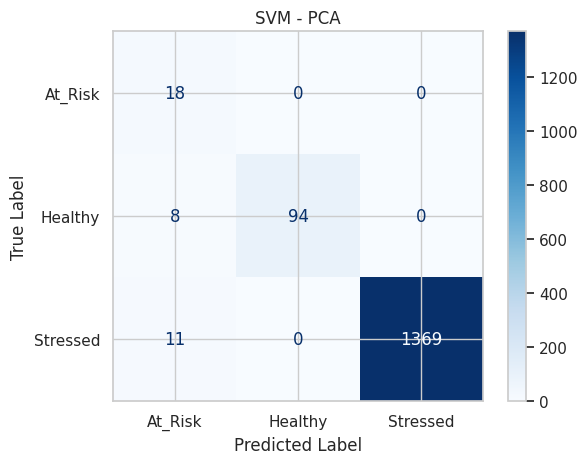

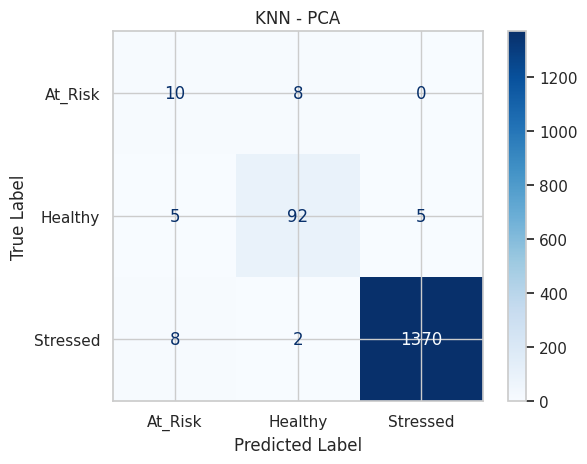

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y_test)


print("\n===== Confusion Matrices: Original Data =====\n")

for name, model in models.items():

    if name == "RandomForest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred, labels=classes)

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, values_format="d")

    plt.title(f"{name} - Original Data")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


print("\n===== Confusion Matrices: PCA =====\n")

for name, model in models.items():

    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    cm = confusion_matrix(y_test, y_pred, labels=classes)

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, values_format="d")

    plt.title(f"{name} - PCA")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()



===== ROC Curves: Original Data =====



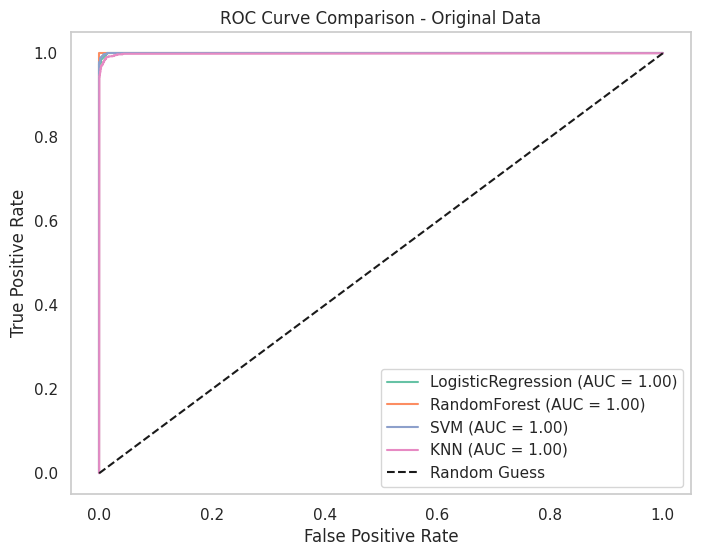


===== ROC Curves: PCA Data =====



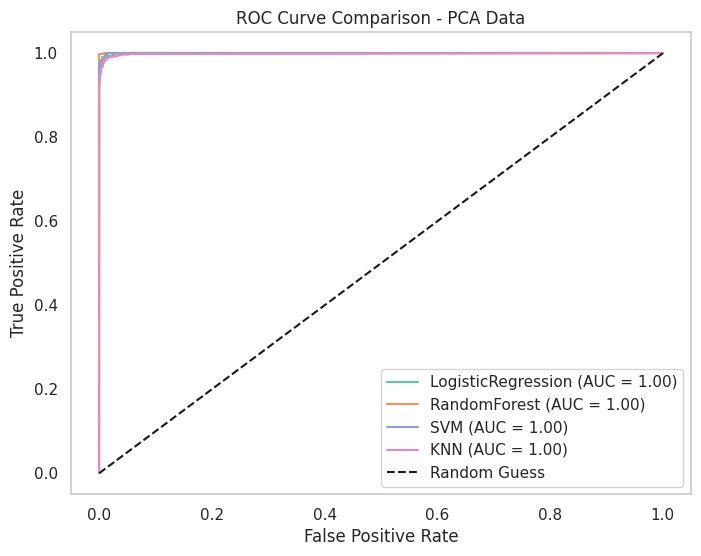

In [61]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y_test)
n_classes = len(classes)


y_test_bin = label_binarize(y_test, classes=classes)


def plot_roc(models_dict, X_train, X_test, y_train, title):

    plt.figure(figsize=(8,6))

    for name, model in models_dict.items():

        clf = OneVsRestClassifier(model)
        clf.fit(X_train, y_train)

        if hasattr(clf, "predict_proba"):
            y_score = clf.predict_proba(X_test)
        else:
            y_score = clf.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")


    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()


print("\n===== ROC Curves: Original Data =====\n")

plot_roc(
    models,
    X_train_scaled,
    X_test_scaled,
    y_train,
    "ROC Curve Comparison - Original Data"
)


print("\n===== ROC Curves: PCA Data =====\n")

plot_roc(
    models,
    X_train_pca,
    X_test_pca,
    y_train,
    "ROC Curve Comparison - PCA Data"
)
